In [1]:
%pip install -q pyts dtaidistance

������ ������� ��࠭��: 1251
Note: you may need to restart the kernel to use updated packages.


# Домашнее задание

1. Генерим 21 сигналов (временных рядов), 3 класса по 7 образцов в каждом. 
Постарайтесь сделать их как можно более похожими, и в тоже время различными. 

1. Рассчитываем расстояние между ними по формуле Евклида и с помощью DTW

1. Описываем кратко полученные значения

1. Формируем из нагенеренных временных рядов набор данных для обучения

1. Разбиваем набор на train и test

1. Обучаем  классификаторы KNN с DTW, KNN со стандартной метрикой расстояния, TimeSeriesForest

1. Описываем кратко полученные результаты

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn

warnings.filterwarnings(
    "ignore",
    message=".*force_all_finite.*",
    category=FutureWarning
)

np.random.seed(42)

Генерация сигнала

1 тип - гармонический (косинус)

2 тип - модифицированный синус

3 тип - пульс - сигнал

Для выполнения дз надо нагенерить 21 сигнал, по 7 сигналов каждого типа

In [3]:
def pulse(t):
    """Пульс сигнал"""
    return 1 * (abs(t) < 0.5)

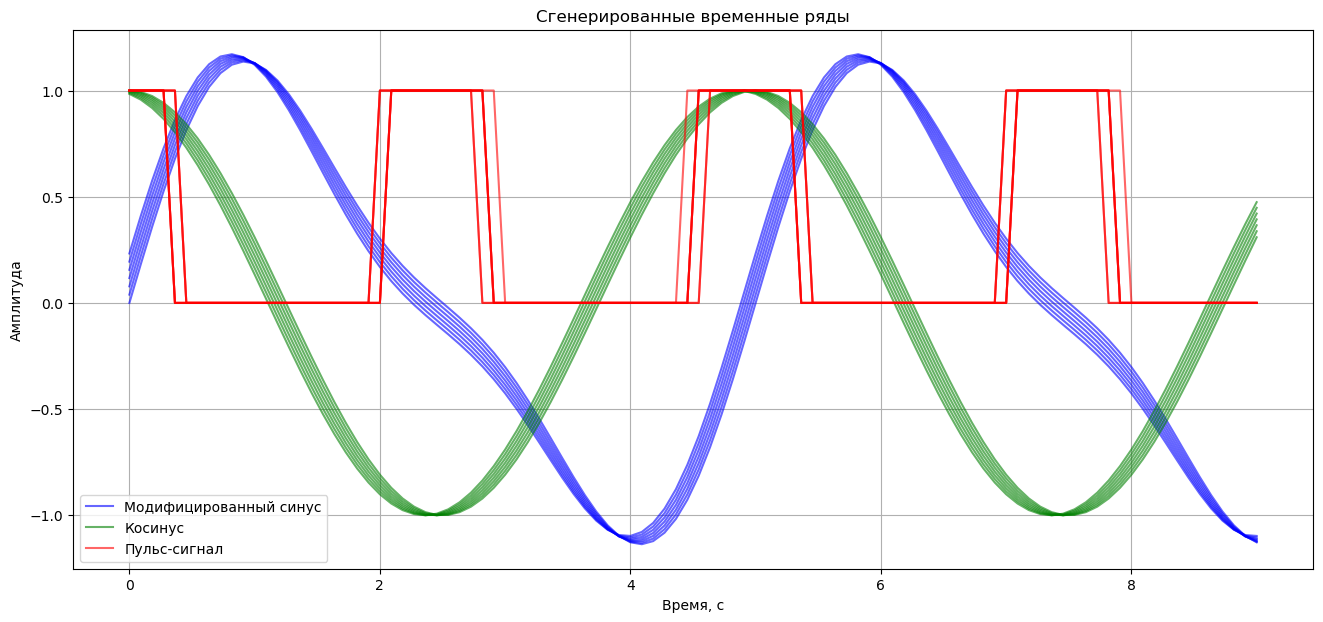

Количество созданных сигналов: 21
Тип данных Ts1: float64


In [4]:
time_index = np.linspace(0, 9, 100)
tseries_list = {"Time": time_index}

N = 7

f0 = 0.2

for i in range(N):
    tseries_list["Tc" + str(i)] = np.cos(
        2 * np.pi * f0 * time_index + i * 0.03
    )

for i in range(N):
    tseries_list["Ts" + str(i)] = (
        np.sin(2 * np.pi * f0 * time_index + i * 0.03)
        + 0.3 * np.sin(4 * np.pi * f0 * time_index + i * 0.03)
    )
for i in range(N):
    tseries_list["Tp" + str(i)] = pulse(
        np.sin(2 * np.pi * f0 * time_index + i * 0.03)
    )

plt.figure(figsize=(16, 7))

for i in range(N):
    plt.plot(
        time_index,
        tseries_list["Ts" + str(i)],
        color="blue",
        alpha=0.6,
        label="Модифицированный синус" if i == 0 else None
    )

for i in range(N):
    plt.plot(
        time_index,
        tseries_list["Tc" + str(i)],
        color="green",
        alpha=0.6,
        label="Косинус" if i == 0 else None
    )

for i in range(N):
    plt.plot(
        time_index,
        tseries_list["Tp" + str(i)],
        color="red",
        alpha=0.6,
        label="Пульс-сигнал" if i == 0 else None
    )

plt.title("Сгенерированные временные ряды")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.legend()
plt.grid(True)
plt.show()

print("Количество созданных сигналов:", len(tseries_list) - 1)
print("Тип данных Ts1:", np.asarray(tseries_list["Ts1"]).dtype)

# Понимание Динамическое искажение (деформация) времени (Dynamic time warping, DTW)

DTW - это метод, который вычисляет оптимальное соответствие между двумя заданными последовательностями (например, временными рядами) с определенными ограничениями и правилами:

1. Каждый индекс из первой последовательности должен быть сопоставлен с одним или несколькими индексами из другой последовательности и наоборот

1. Первый индекс из первой последовательности должен совпадать с первым индексом из другой последовательности (но это не обязательно должно быть его единственным совпадением)

1. Последний индекс из первой последовательности должен совпадать с последним индексом из другой последовательности (но это не обязательно должно быть его единственным совпадением)

1. Отображение индексов из первой последовательности на индексы из другой последовательности должно монотонно возрастать, и наоборот, т. е. если j>i являются индексами из первой последовательности, то в другой последовательности не должно быть двух индексов l> k, так что индекс i совпадает с индексом l, а индекс j - с индексом k, и наоборот.

Рассмотрим два временных ряда $x$ и $x^{\prime}$ соответствующей длины n и m. Предполагается, что все элементы этих рядов лежат в одном и том же  p - одномерном пространство и точные временные метки, в которые происходят наблюдения, не принимаются во внимание, важен только их порядок.

Более формально задача оптимизации записывается в виде:

$
DTW_q({x}, {x}^\prime) =
    \min_{\pi \in \mathcal{A}({x}, {x}^\prime)}
        \left( \sum_{(i, j) \in \pi} d(x_i, x^\prime_j)^q \right)^{\frac{1}{q}}
$

 
Здесь путь выравнивания $\pi$  длины K  представляет собой последовательность K  пары индексов $((i_0,j_0),..,(i_{K-1},j_{K-1}))$
 и  $A(x,x^{\prime})$
 представляет собой набор всех допустимых путей. Чтобы считаться допустимым, путь должен удовлетворять следующим условиям:

Начало (соответственно, конец) временных рядов сопоставляются друг с другом:

$
\pi_0 = (0, 0)
$

$
\pi_{K-1} = (n - 1, m - 1)
$

Последовательность монотонно увеличивается в обоих $i$ и $j$  и все индексы временных рядов должны отображаться хотя бы один раз, что может быть записано как:

$
i_{k-1} \leq i_k \leq i_{k-1} + 1
$

$
j_{k-1} \leq j_k \leq j_{k-1} + 1
$


Другим способом представления  DTW является использование двоичной матрицы, ненулевые элементы которой соответствуют совпадениям между элементами временного ряда. Это представление связано с представлением последовательности индексов, использованным выше:

$
\begin{equation}
(A_\pi)_{i,j} = \left\{ \begin{array}{rl} 1 & \text{ if } (i, j) \in \pi \\
                                      0 & \text{ otherwise}
                        \end{array} \right. \,\,\,\,\,\,\, .
\end{equation}
$

Тогда  DTW может быть выражено через скалярные произведения следующим образом:

$
DTW_q({x}, {x}^\prime) =
    \min_{\pi \in \mathcal{A}({x}, {x}^\prime)}
        \left\langle A_\pi,  D_q({x}, {x}^\prime) \right\rangle^{\frac{1}{q}}
 $ 

Решение поставленной задачи оптимизации может быть найдено с помощью динамического программирования.
Обозначим:

$
R_{i,j} = DTW_q({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})^q
$

где ${x}_{\rightarrow i}$ - обозначает наблюдение ряда до отметки i

Тогда получаем реккурентную формулу:

$
\begin{aligned}
R_{i,j} 
    &= \min_{\pi \in \mathcal{A}({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})}
        \sum_{(k, l) \in \pi} d(x_k, x^\prime_l)^q \\
    &\stackrel{*}{=} d(x_i, x^\prime_j)^q +
        \min_{\pi \in \mathcal{A}({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})}
            \sum_{(k, l) \in \pi[:-1]} d(x_k, x^\prime_l)^q \\
    &\stackrel{**}{=} d(x_i, x^\prime_j)^q +
        \min ({\color{Blue}R_{i-1, j}}, {\color{Red}R_{i, j-1}}, {\color{ForestGreen}R_{i-1, j-1}})
\end{aligned}
$

\* - потому, что последний элемент на допустимом пути должен соответствовать последним элементам ряда.

** - результат условий смежности допустимых путей.

In [5]:
def distance_matrix(x, y, q=2) -> np.ndarray:
    """Вычисляет матрицу локальных расстояний |x[j] - y[i]|**q."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mdist = np.zeros((len(y), len(x)))

    for i in range(len(y)):
        for j in range(len(x)):
            mdist[i, j] = abs(x[j] - y[i]) ** q

    return mdist

In [ ]:
def DTW(x, x_s, q=2, isDTW=True):
    """
    Рассчитывает расстояние между двумя временными рядами.

    x, x_s — сравниваемые временные ряды
    q      — степень локального расстояния
    isDTW  — True: динамическое временное выравнивание,
             False: обычное расстояние точка к точке
    """
    x = np.asarray(x, dtype=float)
    x_s = np.asarray(x_s, dtype=float)

    n = len(x)
    m = len(x_s)
    dist = distance_matrix(x, x_s, q=q)

    if not isDTW:
        if n != m:
            raise ValueError(
                "Для расстояния без DTW ряды должны иметь одинаковую длину."
            )

        path = [(i, i) for i in range(n)]
        distance = np.sum(np.abs(x - x_s) ** q) ** (1 / q)

        return distance, path, dist

    accumulated = np.full((m + 1, n + 1), np.inf)
    accumulated[0, 0] = 0.0

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            accumulated[i, j] = dist[i - 1, j - 1] + min(
                accumulated[i - 1, j],
                accumulated[i, j - 1],
                accumulated[i - 1, j - 1]
            )

    path = []
    i, j = m, n

    while i > 0 or j > 0:
        if i == 0:
            path.append((0, j - 1))
            j -= 1
        elif j == 0:
            path.append((i - 1, 0))
            i -= 1
        else:
            path.append((i - 1, j - 1))
            _, i, j = min(
                (accumulated[i - 1, j], i - 1, j),
                (accumulated[i, j - 1], i, j - 1),
                (accumulated[i - 1, j - 1], i - 1, j - 1),
                key=lambda item: item[0]
            )

    path.reverse()
    distance = accumulated[m, n] ** (1 / q)

    return distance, path, accumulated[1:, 1:]

In [7]:
x = np.abs(np.asarray(tseries_list["Ts1"], dtype=float))
x_s = np.abs(np.asarray(tseries_list["Ts6"], dtype=float))
x_p = np.abs(np.asarray(tseries_list["Tp2"], dtype=float))

s1 = DTW(x, x_s, q=2, isDTW=True)
s2 = DTW(x, x_p, q=2, isDTW=True)

print("DTW-расстояние:")
print(f"Ts1 и Ts6, один класс:    {s1[0]:.4f}")
print(f"Ts1 и Tp2, разные классы: {s2[0]:.4f}")

s11 = DTW(x, x_s, q=2, isDTW=False)
s21 = DTW(x, x_p, q=2, isDTW=False)

print("\nЕвклидово расстояние:")
print(f"Ts1 и Ts6, один класс:    {s11[0]:.4f}")
print(f"Ts1 и Tp2, разные классы: {s21[0]:.4f}")

DTW-расстояние:
Ts1 и Ts6, один класс:    0.2778
Ts1 и Tp2, разные классы: 4.1192

Евклидово расстояние:
Ts1 и Ts6, один класс:    1.0362
Ts1 и Tp2, разные классы: 8.3477


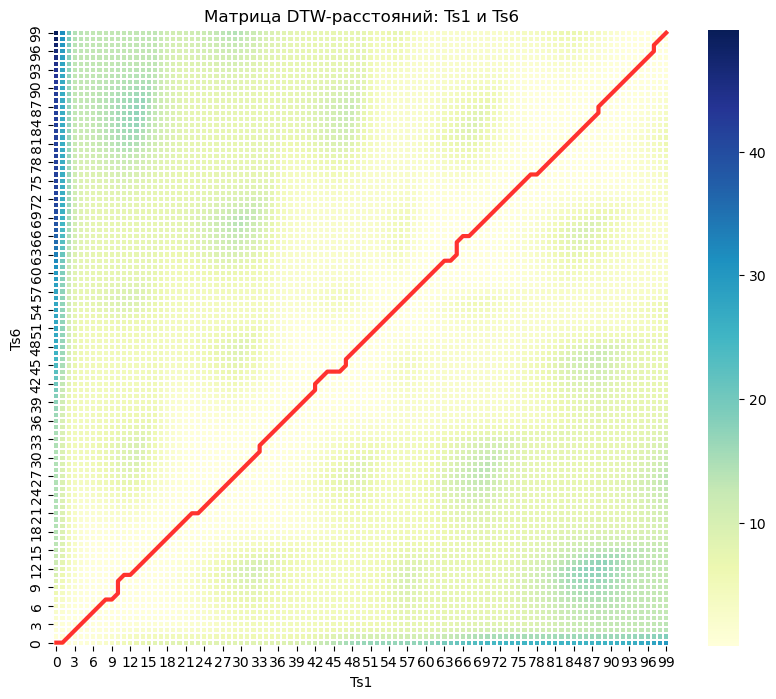

In [8]:
cost_matrix = s1[2]
warp_path = s1[1]

fig, ax = plt.subplots(figsize=(10, 8))
sbn.heatmap(
    cost_matrix,
    square=True,
    linewidths=0.1,
    cmap="YlGnBu",
    ax=ax
)
ax.invert_yaxis()
path_x = [point[1] + 0.5 for point in warp_path]
path_y = [point[0] + 0.5 for point in warp_path]
ax.plot(path_x, path_y, color="red", linewidth=3, alpha=0.8)

plt.title("Матрица DTW-расстояний: Ts1 и Ts6")
plt.xlabel("Ts1")
plt.ylabel("Ts6")
plt.show()

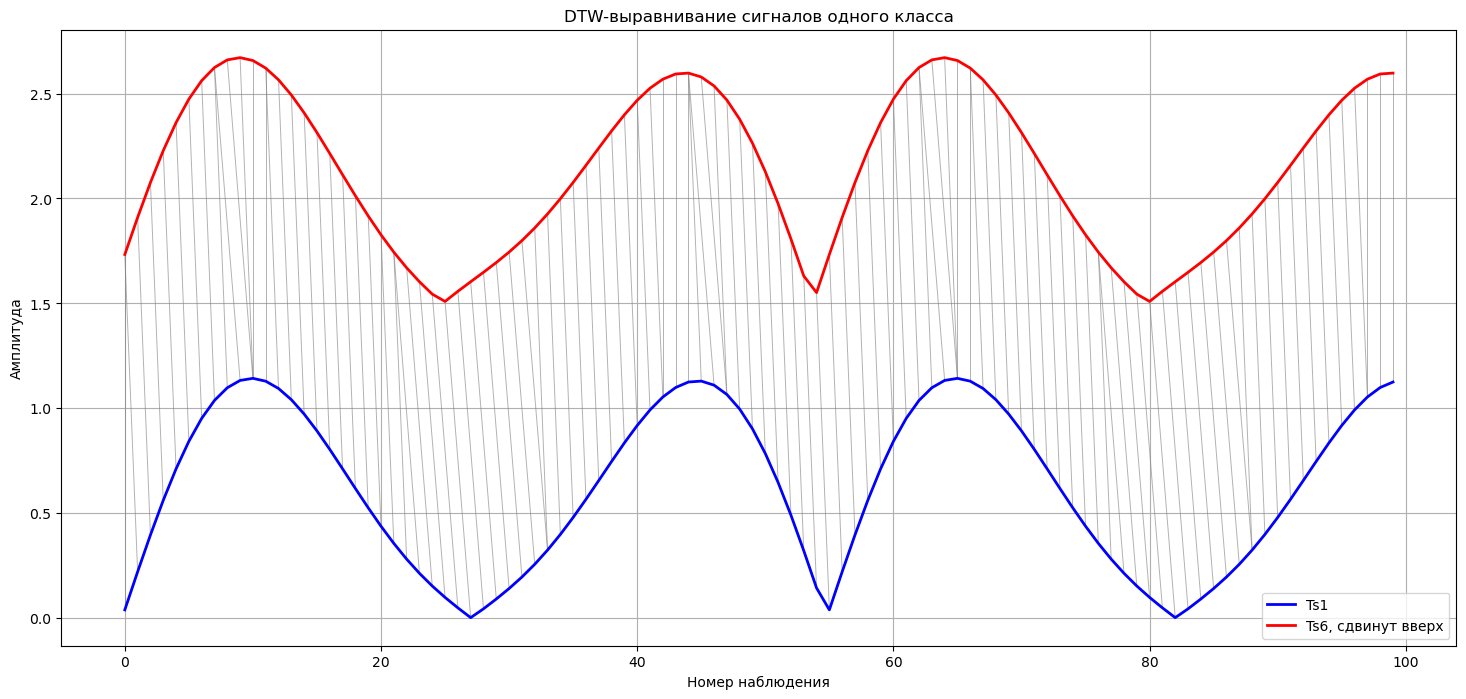

In [9]:
fig, ax = plt.subplots(figsize=(18, 8))

warp_path = s1[1]
x1 = x
x2 = x_s + 1.5 

for row_index, column_index in warp_path:
    ax.plot(
        [column_index, row_index],
        [x1[column_index], x2[row_index]],
        color="gray",
        linewidth=0.7,
        alpha=0.6
    )

ax.plot(x1, color="blue", linewidth=2, label="Ts1")
ax.plot(x2, color="red", linewidth=2, label="Ts6, сдвинут вверх")
ax.set_title("DTW-выравнивание сигналов одного класса")
ax.set_xlabel("Номер наблюдения")
ax.set_ylabel("Амплитуда")
ax.legend()
ax.grid(True)
plt.show()

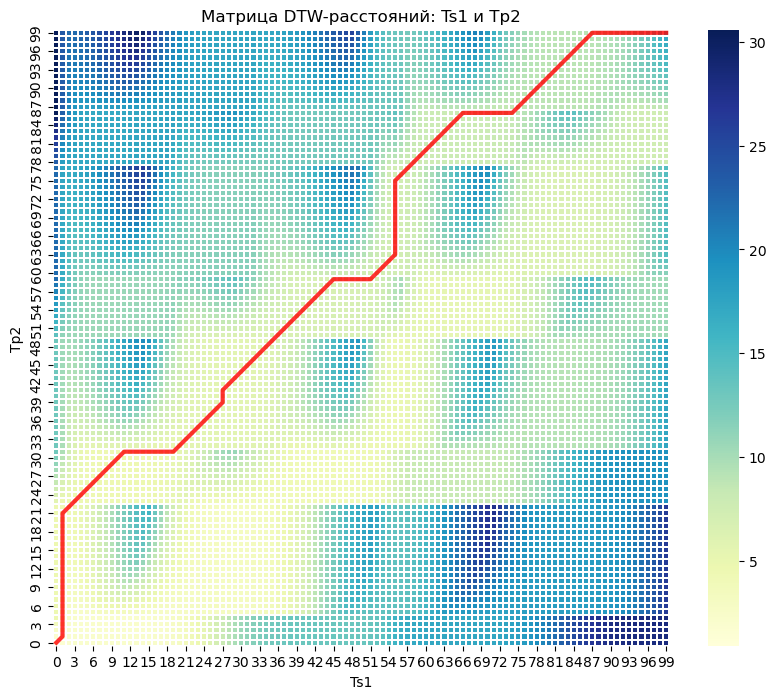

In [10]:
cost_matrix = s2[2]
warp_path = s2[1]

fig, ax = plt.subplots(figsize=(10, 8))
sbn.heatmap(
    cost_matrix,
    square=True,
    linewidths=0.1,
    cmap="YlGnBu",
    ax=ax
)
ax.invert_yaxis()

path_x = [point[1] + 0.5 for point in warp_path]
path_y = [point[0] + 0.5 for point in warp_path]
ax.plot(path_x, path_y, color="red", linewidth=3, alpha=0.8)

plt.title("Матрица DTW-расстояний: Ts1 и Tp2")
plt.xlabel("Ts1")
plt.ylabel("Tp2")
plt.show()

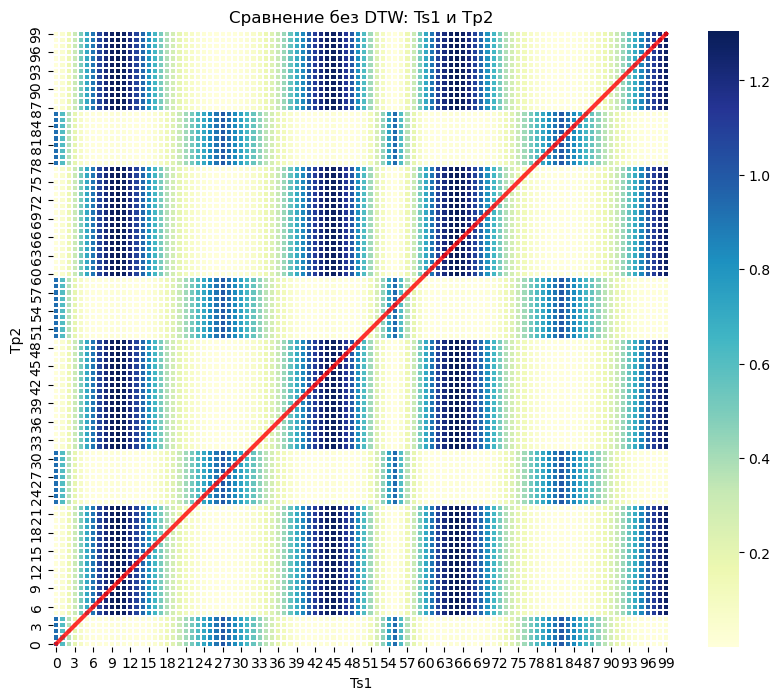

In [11]:
cost_matrix = s21[2]
straight_path = s21[1]

fig, ax = plt.subplots(figsize=(10, 8))
sbn.heatmap(
    cost_matrix,
    square=True,
    linewidths=0.1,
    cmap="YlGnBu",
    ax=ax
)
ax.invert_yaxis()

path_x = [point[1] + 0.5 for point in straight_path]
path_y = [point[0] + 0.5 for point in straight_path]
ax.plot(path_x, path_y, color="red", linewidth=3, alpha=0.8)

plt.title("Сравнение без DTW: Ts1 и Tp2")
plt.xlabel("Ts1")
plt.ylabel("Tp2")
plt.show()

А теперь попробуем вычислить тоже самое, но с помощью встроенных функций Python

In [12]:
from dtaidistance import dtw

builtin_ts1 = np.asarray(tseries_list["Ts1"], dtype=np.double)
builtin_ts6 = np.asarray(tseries_list["Ts6"], dtype=np.double)

distance_same, paths_same = dtw.warping_paths(builtin_ts1, builtin_ts6)

print("Встроенное DTW-расстояние между Ts1 и Ts6:")
print(distance_same)

Встроенное DTW-расстояние между Ts1 и Ts6:
0.27807742324851265


DTW-расстояние между Ts1 и Ts6: 0.19756251265133146


(<Figure size 1000x1000 with 4 Axes>, [<Axes: >, <Axes: >, <Axes: >, <Axes: >])

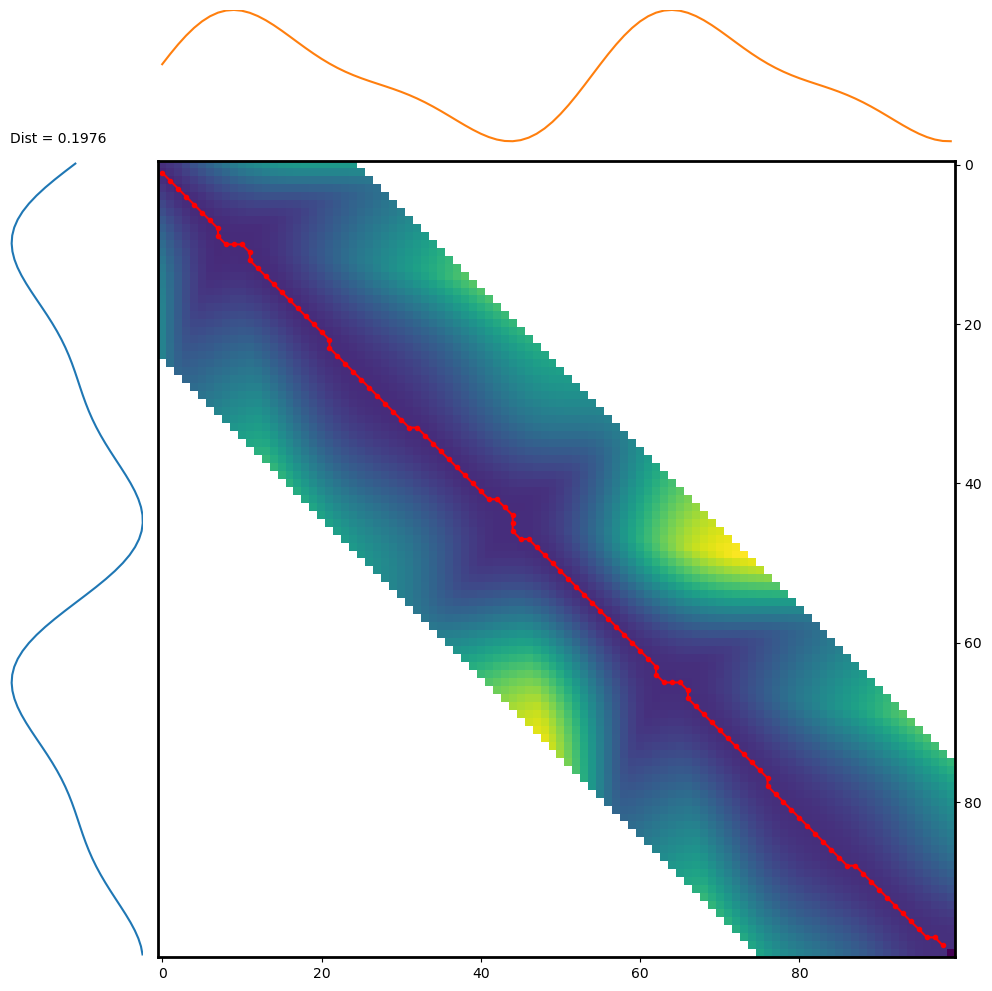

In [ ]:
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis

builtin_ts1 = np.asarray(tseries_list["Ts1"], dtype=np.double)
builtin_ts6 = np.asarray(tseries_list["Ts6"], dtype=np.double)

distance_same, paths_same = dtw.warping_paths(
    builtin_ts1,
    builtin_ts6,
    window=25,
    psi=2
)
best_path_same = dtw.best_path(paths_same)

print("DTW-расстояние между Ts1 и Ts6:", distance_same)

dtwvis.plot_warpingpaths(
    builtin_ts1,
    builtin_ts6,
    paths_same,
    path=best_path_same
)

In [14]:
builtin_tp2 = np.asarray(tseries_list["Tp2"], dtype=np.double)

distance_different, paths_different = dtw.warping_paths(
    builtin_ts1,
    builtin_tp2
)

print("Встроенное DTW-расстояние между Ts1 и Tp2:")
print(distance_different)

Встроенное DTW-расстояние между Ts1 и Tp2:
5.989777818414596


DTW-расстояние между Ts1 и Tp2: 5.662857275048453


(<Figure size 1000x1000 with 4 Axes>, [<Axes: >, <Axes: >, <Axes: >, <Axes: >])

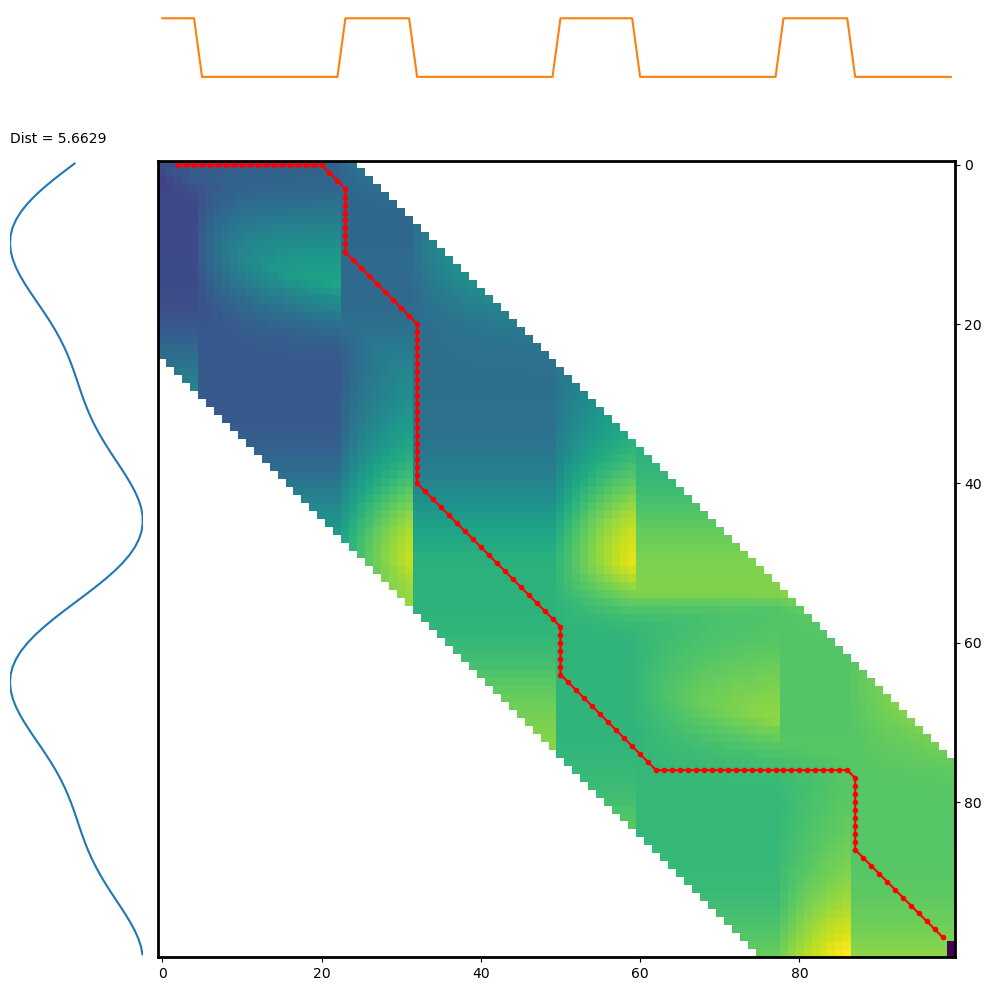

In [15]:
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis

builtin_ts1 = np.asarray(tseries_list["Ts1"], dtype=np.double)
builtin_tp2 = np.asarray(tseries_list["Tp2"], dtype=np.double)

distance_different, paths_different = dtw.warping_paths(
    builtin_ts1,
    builtin_tp2,
    window=25,
    psi=2
)
best_path_different = dtw.best_path(paths_different)

print("DTW-расстояние между Ts1 и Tp2:", distance_different)

dtwvis.plot_warpingpaths(
    builtin_ts1,
    builtin_tp2,
    paths_different,
    path=best_path_different
)

In [16]:
X = []
Y = []

for name in tseries_list:
    if name != "Time":
        X.append(tseries_list[name])

        signal_class = name[:-1]
        if signal_class == "Ts":
            Y.append(0)  
        elif signal_class == "Tc":
            Y.append(1)  
        else:
            Y.append(2)  

X = np.asarray(X, dtype=float)
Y = np.asarray(Y, dtype=int)
np.random.seed(42)
indexes = np.arange(len(Y))
np.random.shuffle(indexes)

train_indexes = indexes[:-5]
test_indexes = indexes[-5:]

X_train = X[train_indexes]
X_test = X[test_indexes]
y_train = Y[train_indexes]
y_test = Y[test_indexes]

print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Размер y_train:", y_train.shape)
print("Размер y_test:", y_test.shape)

print("\nКлассы в обучающей выборке:", y_train)
print("Классы в тестовой выборке:", y_test)
print("\n0 — модифицированный синус, 1 — косинус, 2 — пульс-сигнал")

Размер X_train: (16, 100)
Размер X_test: (5, 100)
Размер y_train: (16,)
Размер y_test: (5,)

Классы в обучающей выборке: [1 2 2 1 0 1 0 1 2 2 0 1 0 2 1 0]
Классы в тестовой выборке: [0 0 2 2 1]

0 — модифицированный синус, 1 — косинус, 2 — пульс-сигнал


In [17]:
warnings.filterwarnings(
    "ignore",
    message=".*force_all_finite.*",
    category=FutureWarning
)

In [18]:
from pyts.classification import KNeighborsClassifier

clf_dtw = KNeighborsClassifier(
    n_neighbors=1,
    metric="dtw"
)

clf_dtw.fit(X_train, y_train)
pred_dtw = clf_dtw.predict(X_test)
accuracy_dtw = clf_dtw.score(X_test, y_test)

print("KNN + DTW")
print(f"Accuracy: {accuracy_dtw:.4f}")
print("Истинные классы:     ", y_test)
print("Предсказанные классы:", pred_dtw)
print(
    "Вероятности для третьего тестового объекта:",
    clf_dtw.predict_proba(X_test[2].reshape(1, -1))
)
print("Истинный класс третьего объекта:", y_test[2])

KNN + DTW
Accuracy: 1.0000
Истинные классы:      [0 0 2 2 1]
Предсказанные классы: [0 0 2 2 1]
Вероятности для третьего тестового объекта: [[0. 0. 1.]]
Истинный класс третьего объекта: 2


In [19]:
from pyts.classification import TimeSeriesForest
clf_forest = TimeSeriesForest(random_state=43)

clf_forest.fit(X_train, y_train)
pred_forest = clf_forest.predict(X_test)
accuracy_forest = clf_forest.score(X_test, y_test)

print("TimeSeriesForest")
print(f"Accuracy: {accuracy_forest:.4f}")
print("Истинные классы:     ", y_test)
print("Предсказанные классы:", pred_forest)
print(
    "Вероятности для третьего тестового объекта:",
    clf_forest.predict_proba(X_test[2].reshape(1, -1))
)
print("Истинный класс третьего объекта:", y_test[2])

TimeSeriesForest
Accuracy: 1.0000
Истинные классы:      [0 0 2 2 1]
Предсказанные классы: [0 0 2 2 1]
Вероятности для третьего тестового объекта: [[0.03  0.008 0.962]]
Истинный класс третьего объекта: 2


In [20]:
from pyts.classification import KNeighborsClassifier
clf_eucl = KNeighborsClassifier(
    n_neighbors=1,
    metric="euclidean"
)

clf_eucl.fit(X_train, y_train)
pred_eucl = clf_eucl.predict(X_test)
accuracy_eucl = clf_eucl.score(X_test, y_test)

print("KNN + Euclidean")
print(f"Accuracy: {accuracy_eucl:.4f}")
print("Истинные классы:     ", y_test)
print("Предсказанные классы:", pred_eucl)
print(
    "Вероятности для третьего тестового объекта:",
    clf_eucl.predict_proba(X_test[2].reshape(1, -1))
)
print("Истинный класс третьего объекта:", y_test[2])

KNN + Euclidean
Accuracy: 1.0000
Истинные классы:      [0 0 2 2 1]
Предсказанные классы: [0 0 2 2 1]
Вероятности для третьего тестового объекта: [[0. 0. 1.]]
Истинный класс третьего объекта: 2


У каждой модели метрика accuracy имеет одно и то же значение,это значит что классы довольно сильно отличаются друг от друга